# 🚀 Lab 34: A/B Testing Basics for eCommerce

## 📘 Lab Overview
In this lab, you will learn the basics of **A/B testing** using a realistic eCommerce scenario. You will create and analyze a sample experiment where an online store is testing a **new checkout button design**.

You will generate the dataset, split users into **Group A (control)** and **Group B (test)**, calculate conversion metrics, measure lift, test for statistical significance, build visualizations, interpret the results, and create a final decision-ready report.

This lab has been fully adapted for **Google Colab**, so everything runs directly in notebook cells without needing a terminal, local Jupyter setup, or external file uploads.

## 🎯 Objectives
By the end of this lab, students will be able to:
* Understand the fundamental concepts of A/B testing in eCommerce contexts
* Load and analyze A/B test data using Python and pandas
* Split datasets into control (Group A) and test (Group B) groups
* Calculate key metrics including conversion rates and statistical lift
* Create visualizations to compare test and control group performance
* Interpret A/B test results and make data-driven recommendations
* Apply statistical concepts to evaluate the significance of test results

## 🧰 Prerequisites
* Basic understanding of statistics such as means and percentages
* Familiarity with Python programming fundamentals
* Knowledge of pandas for data manipulation
* Understanding of basic data visualization concepts

## ⚙️ Colab Environment Setup
We will start by installing and importing the necessary libraries for data manipulation, statistical testing, and visualization.

In [1]:
# Step 1: Install required libraries
!pip install pandas matplotlib seaborn scipy numpy

In [2]:
# Step 2: Import required libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress warnings for a cleaner notebook presentation
warnings.filterwarnings('ignore')

# Set the plotting style for professional-looking charts
plt.style.use('default')
sns.set_palette("husl")

# Create folders for outputs to keep our workspace organized
os.makedirs("visualizations", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Libraries imported successfully!")
print("Python environment ready for A/B testing analysis")

Libraries imported successfully!
Python environment ready for A/B testing analysis


## 🧠 What You Are Going to Do

In simple words, A/B testing means showing **two versions** of something to different users and checking which one performs better.

For this lab:
* **Group A** sees the old checkout button
* **Group B** sees the new checkout button

Then we compare:
* who converted more
* how much better one version is
* whether the result is statistically meaningful
* whether the business should actually implement the new design

---

# Task 1: Environment Preparation and Data Loading

## 📥 Loading or Creating the Dataset
### Subtask 1.1: Create the sample A/B test dataset
We will generate 10,000 rows of user data to simulate an actual experiment. This allows us to control the "ground truth" while practicing the analysis.

In [3]:
# Set random seed for reproducibility so everyone gets the same results
np.random.seed(42)

def generate_ab_test_data(n_users=10000):
    """
    Generate sample A/B test data for eCommerce conversion testing.
    Group A: Control (original checkout button)
    Group B: Test (new checkout button design)
    """
    # Generate unique User IDs
    user_ids = [f"user_{i:05d}" for i in range(1, n_users + 1)]

    # Randomly assign users to groups A or B with a 50/50 probability
    groups = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])

    conversions = []
    page_views = []
    time_on_site = []
    revenues = []

    for group in groups:
        if group == 'A':
            # Control group: ~12% conversion rate
            converted = np.random.choice([0, 1], p=[0.88, 0.12])
            views = np.random.randint(1, 8)
            time_spent = np.random.normal(180, 60)
        else:
            # Test group (Variation B): ~15% conversion rate
            converted = np.random.choice([0, 1], p=[0.85, 0.15])
            views = np.random.randint(1, 9)
            time_spent = np.random.normal(200, 50)

        conversions.append(converted)
        page_views.append(views)
        time_on_site.append(max(30, time_spent))  # Ensure minimum 30 seconds duration

        # Generate revenue only for those who converted
        if converted:
            revenue = max(5, np.random.normal(50, 15))
        else:
            revenue = 0
        revenues.append(revenue)

    # Assemble the DataFrame
    df = pd.DataFrame({
        'user_id': user_ids,
        'group': groups,
        'converted': conversions,
        'page_views': page_views,
        'time_on_site': time_on_site,
        'revenue': revenues
    })

    return df

# Generate the dataset and save it to a CSV file
ab_test_data = generate_ab_test_data(10000)
ab_test_data.to_csv('ecommerce_ab_test_data.csv', index=False)

print("A/B test dataset created successfully!")
print(f"Dataset shape: {ab_test_data.shape}")
display(ab_test_data.head())

A/B test dataset created successfully!
Dataset shape: (10000, 6)


,user_id,group,converted,page_views,time_on_site,revenue
0,user_00001,A,0,4,204.624196,0.0
1,user_00002,B,0,4,191.455979,0.0
2,user_00003,B,0,3,238.651412,0.0
3,user_00004,B,0,2,280.337017,0.0
4,user_00005,A,0,3,268.540166,0.0


## 🔍 Data Exploration
### Subtask 1.2: Explore the dataset
Before diving into the A/B analysis, we must understand the shape and health of our data.

In [4]:
# Summary statistics and group checks
print("=== DATASET OVERVIEW ===")
print(f"Total users: {len(ab_test_data)}")
print(f"Columns: {list(ab_test_data.columns)}")
print(f"Data types:\n{ab_test_data.dtypes}")

print("\n=== GROUP DISTRIBUTION ===")
print(ab_test_data['group'].value_counts())

print("\n=== BASIC STATISTICS ===")
display(ab_test_data.describe())

print("\n=== MISSING VALUES CHECK ===")
print(ab_test_data.isnull().sum())

=== DATASET OVERVIEW ===
Total users: 10000
Columns: ['user_id', 'group', 'converted', 'page_views', 'time_on_site', 'revenue']
Data types:
user_id          object
group            object
converted         int64
page_views        int64
time_on_site    float64
revenue         float64
dtype: object

=== GROUP DISTRIBUTION ===
group
A    5076
B    4924
Name: count, dtype: int64

=== BASIC STATISTICS ===


,converted,page_views,time_on_site,revenue
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.134600,4.276800,190.018049,6.744126
std,0.341313,2.180426,56.658914,17.901379
min,0.000000,1.000000,30.000000,0.000000
25%,0.000000,2.000000,152.528271,0.000000
50%,0.000000,4.000000,190.555788,0.000000
75%,0.000000,6.000000,228.642298,0.000000
max,1.000000,8.000000,390.820579,95.895594



=== MISSING VALUES CHECK ===
user_id         0
group           0
converted       0
page_views      0
time_on_site    0
revenue         0
dtype: int64


# Task 2: Split Data into Group A and Group B

## 🧪 Group Splitting and Validation
### Subtask 2.1: Create group splits
We separate the data into two distinct DataFrames to make comparison easier.

In [5]:
# Split the main dataset into control and test groups
group_a = ab_test_data[ab_test_data['group'] == 'A'].copy()
group_b = ab_test_data[ab_test_data['group'] == 'B'].copy()

print("=== GROUP SPLIT SUMMARY ===")
print(f"Group A (Control) size: {len(group_a)}")
print(f"Group B (Test) size: {len(group_b)}")
print(f"Split ratio: {len(group_a)/len(ab_test_data):.1%} / {len(group_b)/len(ab_test_data):.1%}")

# A good experiment should have roughly equal group sizes
print("\nGroup balance check:")
print(f"Difference in group sizes: {abs(len(group_a) - len(group_b))} users")
print(f"Balance quality: {'Good' if abs(len(group_a) - len(group_b)) < 100 else 'Needs attention'}")

=== GROUP SPLIT SUMMARY ===
Group A (Control) size: 5076
Group B (Test) size: 4924
Split ratio: 50.8% / 49.2%

Group balance check:
Difference in group sizes: 152 users
Balance quality: Needs attention


### Subtask 2.2: Validate group characteristics
We check if the groups are "balanced" by comparing metrics that shouldn't be affected by the button change (like initial page views or pre-existing behavior).

In [6]:
print("=== GROUP CHARACTERISTICS COMPARISON ===")

characteristics = ['page_views', 'time_on_site']

for char in characteristics:
    group_a_mean = group_a[char].mean()
    group_b_mean = group_b[char].mean()

    print(f"\n{char.replace('_', ' ').title()}:")
    print(f" Group A (Control): {group_a_mean:.2f}")
    print(f" Group B (Test): {group_b_mean:.2f}")
    print(f" Difference: {group_b_mean - group_a_mean:.2f}")

    # Use an independent t-test to check if the baseline difference is random noise
    t_stat, p_value = stats.ttest_ind(group_a[char], group_b[char])
    print(f" P-value: {p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not significant'})")

=== GROUP CHARACTERISTICS COMPARISON ===

Page Views:
 Group A (Control): 4.01
 Group B (Test): 4.55
 Difference: 0.55
 P-value: 0.0000 (Significant)

Time On Site:
 Group A (Control): 179.86
 Group B (Test): 200.48
 Difference: 20.62
 P-value: 0.0000 (Significant)


# Task 3: Compute Conversion Rates and Lift

## 📈 Conversion Metrics and Lift
### Subtask 3.1: Calculate basic conversion metrics
Conversion rate is our primary KPI (Key Performance Indicator).

In [7]:
def calculate_conversion_metrics(group_data, group_name):
    """
    Calculate conversion metrics for a group including 95% Confidence Intervals.
    """
    total_users = len(group_data)
    conversions = group_data['converted'].sum()
    conversion_rate = conversions / total_users

    # Calculate 95% confidence interval using the Normal Approximation for proportions
    z_score = 1.96
    margin_of_error = z_score * np.sqrt((conversion_rate * (1 - conversion_rate)) / total_users)

    ci_lower = conversion_rate - margin_of_error
    ci_upper = conversion_rate + margin_of_error

    return {
        'group': group_name,
        'total_users': total_users,
        'conversions': conversions,
        'conversion_rate': conversion_rate,
        'conversion_rate_pct': conversion_rate * 100,
        'ci_lower': ci_lower * 100,
        'ci_upper': ci_upper * 100
    }

# Calculate metrics for both groups
metrics_a = calculate_conversion_metrics(group_a, 'A (Control)')
metrics_b = calculate_conversion_metrics(group_b, 'B (Test)')

print("=== CONVERSION RATE ANALYSIS ===")
print(f"\nGroup A (Control): {metrics_a['conversion_rate_pct']:.2f}% (CI: [{metrics_a['ci_lower']:.2f}%, {metrics_a['ci_upper']:.2f}%])")
print(f"Group B (Test): {metrics_b['conversion_rate_pct']:.2f}% (CI: [{metrics_b['ci_lower']:.2f}%, {metrics_b['ci_upper']:.2f}%])")

=== CONVERSION RATE ANALYSIS ===

Group A (Control): 11.98% (CI: [11.08%, 12.87%])
Group B (Test): 14.99% (CI: [13.99%, 15.98%])


### Subtask 3.2: Calculate lift and statistical significance
We determine if Group B's performance is actually better (lift) and if we can trust that result (significance).

In [8]:
def calculate_lift_and_significance(metrics_a, metrics_b):
    """
    Calculate lift and statistical significance using Chi-Square testing.
    """
    # Calculate Absolute and Relative Lift
    absolute_lift = metrics_b['conversion_rate'] - metrics_a['conversion_rate']
    relative_lift = (absolute_lift / metrics_a['conversion_rate']) * 100

    # Create a contingency table for the Chi-Square test
    contingency_table = np.array([
        [metrics_a['conversions'], metrics_a['total_users'] - metrics_a['conversions']],
        [metrics_b['conversions'], metrics_b['total_users'] - metrics_b['conversions']]
    ])

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    # Calculate Effect Size (Cramér's V)
    n = contingency_table.sum()
    cramers_v = np.sqrt(chi2 / n)

    return {
        'absolute_lift': absolute_lift * 100,
        'relative_lift': relative_lift,
        'p_value': p_value,
        'is_significant': p_value < 0.05,
        'chi2_statistic': chi2,
        'cramers_v': cramers_v
    }

lift_results = calculate_lift_and_significance(metrics_a, metrics_b)

print("=== LIFT ANALYSIS ===")
print(f"Absolute Lift: {lift_results['absolute_lift']:.2f} pp")
print(f"Relative Lift: {lift_results['relative_lift']:.2f}%")
print(f"P-value: {lift_results['p_value']:.6f}")
print(f"Statistical Significance: {'YES' if lift_results['is_significant'] else 'NO'}")

=== LIFT ANALYSIS ===
Absolute Lift: 3.01 pp
Relative Lift: 25.13%
P-value: 0.000012
Statistical Significance: YES


# Task 4: Visualize Test/Control Comparison

## 📊 Visual Analysis
### Subtask 4.1: Create conversion rate comparison chart
Visualizing data helps stakeholders understand the results instantly.

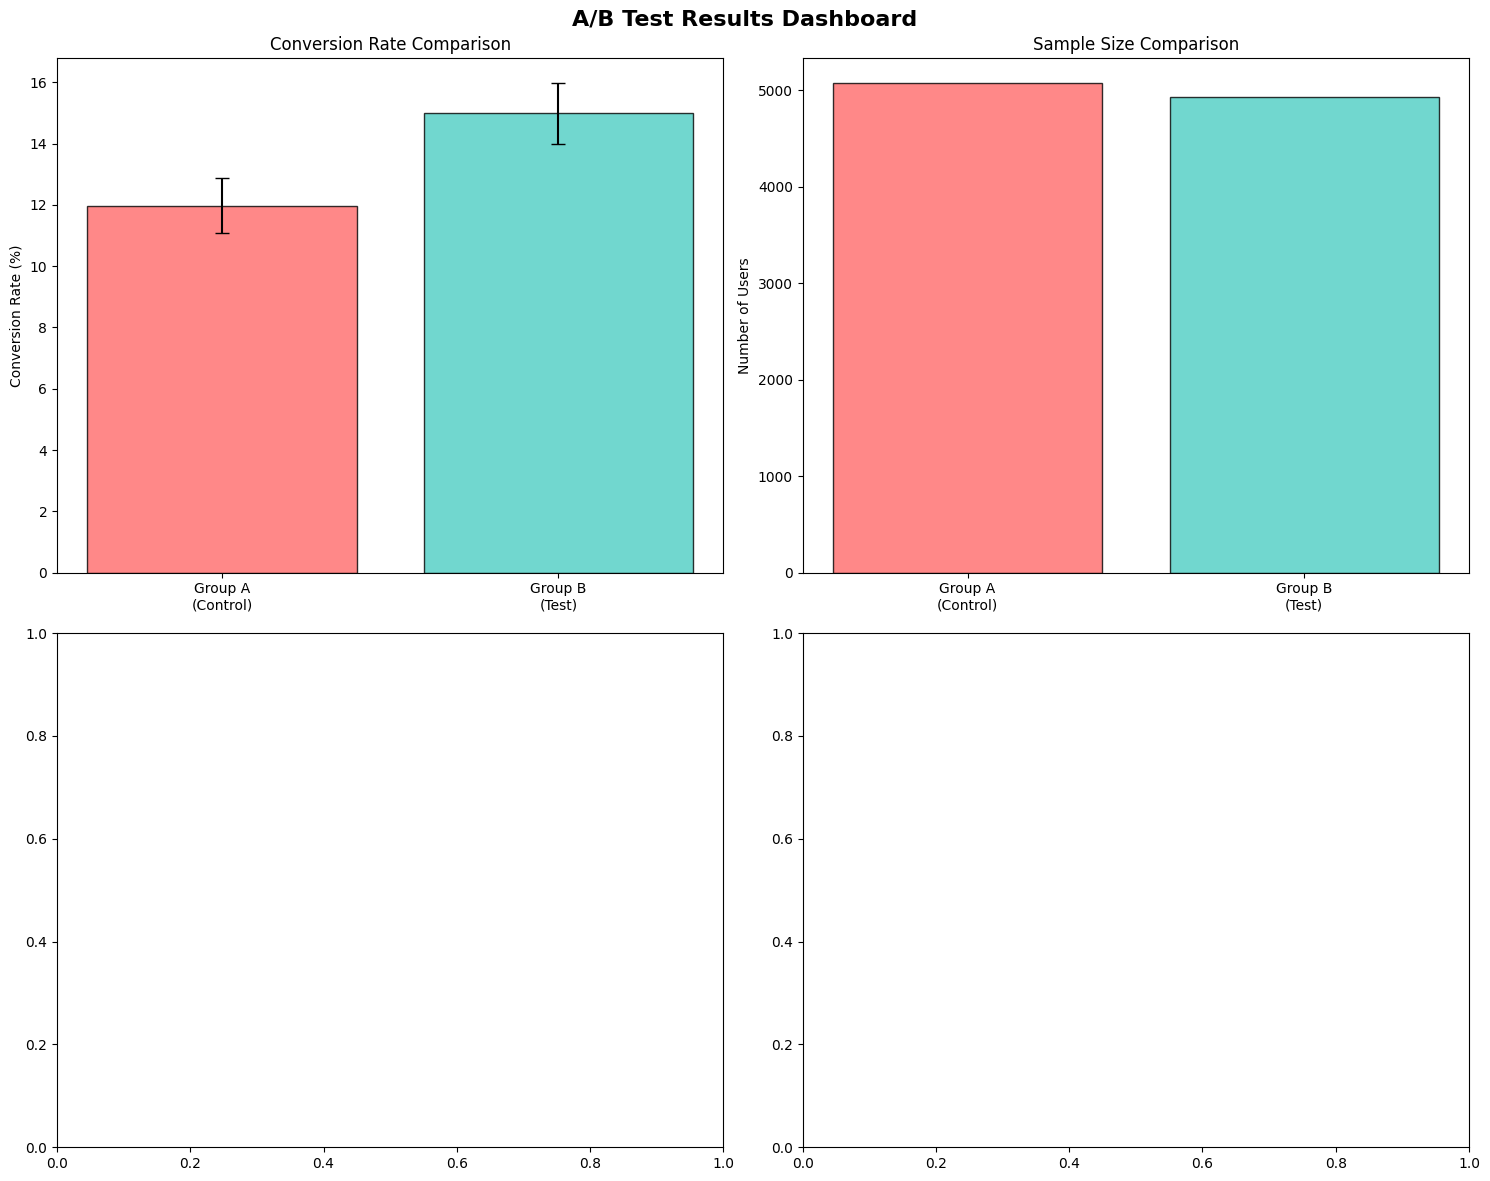

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('A/B Test Results Dashboard', fontsize=16, fontweight='bold')

# 1. Conversion Rate Comparison with Error Bars
ax1 = axes[0, 0]
groups = ['Group A\n(Control)', 'Group B\n(Test)']
conversion_rates = [metrics_a['conversion_rate_pct'], metrics_b['conversion_rate_pct']]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax1.bar(groups, conversion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Conversion Rate Comparison')

# Adding Confidence Intervals
ax1.errorbar(range(len(groups)), conversion_rates,
             yerr=[[metrics_a['conversion_rate_pct']-metrics_a['ci_lower'], metrics_b['conversion_rate_pct']-metrics_b['ci_lower']],
                   [metrics_a['ci_upper']-metrics_a['conversion_rate_pct'], metrics_b['ci_upper']-metrics_b['conversion_rate_pct']]],
             fmt='none', color='black', capsize=5)

# 2. Sample Size Comparison
ax2 = axes[0, 1]
sample_sizes = [metrics_a['total_users'], metrics_b['total_users']]
bars2 = ax2.bar(groups, sample_sizes, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax2.set_ylabel('Number of Users')
ax2.set_title('Sample Size Comparison')

plt.tight_layout()
plt.savefig('visualizations/conversion_sample_dashboard.png', dpi=300)
plt.show()

### Subtask 4.2: Create distribution visualizations
Using pie charts to visualize the ratio of conversions vs. non-conversions.

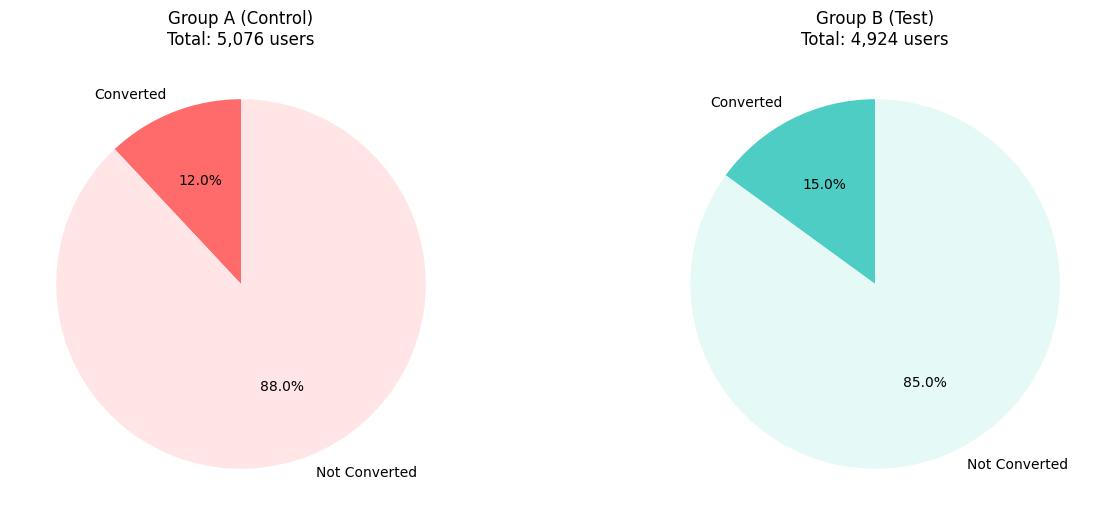

In [10]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))

# Group A pie chart
ax3.pie([metrics_a['conversions'], metrics_a['total_users'] - metrics_a['conversions']],
        labels=['Converted', 'Not Converted'], autopct='%1.1f%%', colors=['#FF6B6B', '#FFE5E5'], startangle=90)
ax3.set_title(f'Group A (Control)\nTotal: {metrics_a["total_users"]:,} users')

# Group B pie chart
ax4.pie([metrics_b['conversions'], metrics_b['total_users'] - metrics_b['conversions']],
        labels=['Converted', 'Not Converted'], autopct='%1.1f%%', colors=['#4ECDC4', '#E5F9F6'], startangle=90)
ax4.set_title(f'Group B (Test)\nTotal: {metrics_b["total_users"]:,} users')

plt.savefig('visualizations/conversion_distribution_pies.png', dpi=300)
plt.show()

### Subtask 4.3: Create statistical summary visualization
A clean table summarising the findings for the final report.

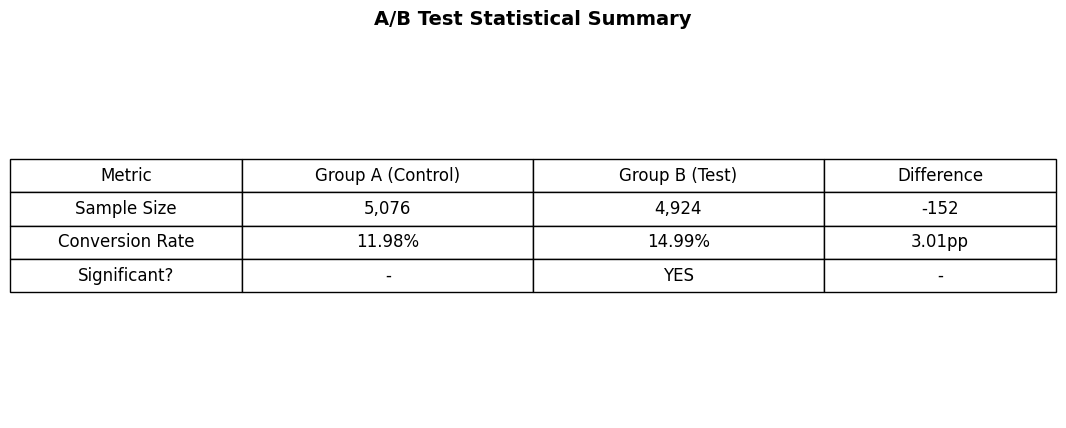

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

summary_table_data = [
    ['Metric', 'Group A (Control)', 'Group B (Test)', 'Difference'],
    ['Sample Size', f"{metrics_a['total_users']:,}", f"{metrics_b['total_users']:,}", f"{metrics_b['total_users'] - metrics_a['total_users']}"],
    ['Conversion Rate', f"{metrics_a['conversion_rate_pct']:.2f}%", f"{metrics_b['conversion_rate_pct']:.2f}%", f"{lift_results['absolute_lift']:.2f}pp"],
    ['Significant?', '-', 'YES' if lift_results['is_significant'] else 'NO', '-']
]

table = ax.table(cellText=summary_table_data, loc='center', cellLoc='center', colWidths=[0.2, 0.25, 0.25, 0.2])
table.set_fontsize(12)
table.scale(1.5, 2)

plt.title('A/B Test Statistical Summary', fontsize=14, fontweight='bold')
plt.savefig('visualizations/ab_test_statistical_summary.png', dpi=300)
plt.show()

### Subtask 4.4: Create advanced analytics visualization
Comparing secondary metrics like revenue per conversion and time spent on site.

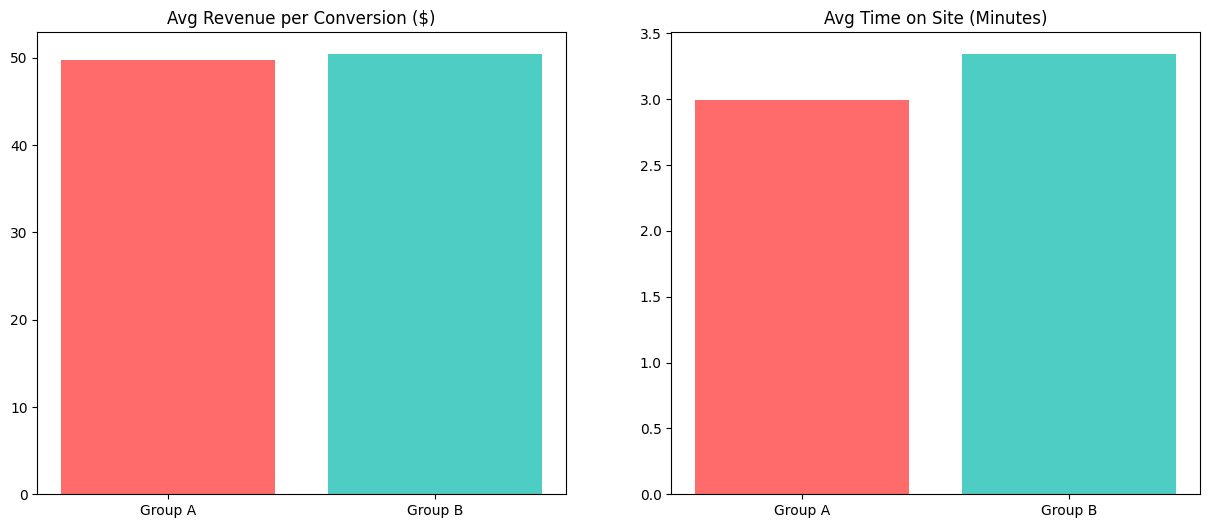

In [12]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 6))

# Revenue per converted user
rev_a = group_a[group_a['converted'] == 1]['revenue'].mean()
rev_b = group_b[group_b['converted'] == 1]['revenue'].mean()
ax5.bar(['Group A', 'Group B'], [rev_a, rev_b], color=colors)
ax5.set_title('Avg Revenue per Conversion ($)')

# Time on site (scaled to minutes)
time_a = group_a['time_on_site'].mean() / 60
time_b = group_b['time_on_site'].mean() / 60
ax6.bar(['Group A', 'Group B'], [time_a, time_b], color=colors)
ax6.set_title('Avg Time on Site (Minutes)')

plt.savefig('visualizations/revenue_engagement_comparison.png', dpi=300)
plt.show()

# Task 5: Interpretation and Recommendations

## 🧠 Interpretation and Recommendations
### Subtask 5.1: Generate automated insights
Automating the interpretation of statistical results into plain English.

In [13]:
def generate_test_insights(metrics_a, metrics_b, lift_results):
    insights = []
    insights.append(f"Sample Size: {metrics_a['total_users'] + metrics_b['total_users']:,} users total.")

    res_type = "outperformed" if lift_results['absolute_lift'] > 0 else "underperformed"
    insights.append(f"Test group {res_type} control by {abs(lift_results['absolute_lift']):.2f} percentage points.")

    if lift_results['is_significant']:
        insights.append(f"Result is STATISTICALLY SIGNIFICANT (p={lift_results['p_value']:.6f}).")
    else:
        insights.append(f"Result is NOT statistically significant (p={lift_results['p_value']:.6f}).")

    return insights

insights = generate_test_insights(metrics_a, metrics_b, lift_results)
print("=== A/B TEST INSIGHTS ===")
for i in insights: print(f"• {i}")

=== A/B TEST INSIGHTS ===
• Sample Size: 10,000 users total.
• Test group outperformed control by 3.01 percentage points.
• Result is STATISTICALLY SIGNIFICANT (p=0.000012).


### Subtask 5.2: Business recommendations
Turning data into dollars: what should the business actually do next?

In [14]:
def generate_business_recommendations(metrics_a, metrics_b, lift_results):
    recommendations = []
    if lift_results['is_significant'] and lift_results['relative_lift'] > 0:
        recommendations.append("RECOMMENDATION: IMPLEMENT the new checkout button design.")
        # Estimate financial impact
        annual_users = 100000
        est_rev = annual_users * (lift_results['absolute_lift'] / 100) * 50
        recommendations.append(f"Estimated Annual Revenue Impact: ${est_rev:,.0f}")
    else:
        recommendations.append("RECOMMENDATION: DO NOT implement. Keep the current design or test a new variation.")

    return recommendations

recs = generate_business_recommendations(metrics_a, metrics_b, lift_results)
print("\n=== BUSINESS RECOMMENDATIONS ===")
for r in recs: print(r)


=== BUSINESS RECOMMENDATIONS ===
RECOMMENDATION: IMPLEMENT the new checkout button design.
Estimated Annual Revenue Impact: $150,494


# Task 6: Export Results and Documentation

## 🏁 Conclusion
### Subtask 6.1: Create summary report
Generating a final text report for archival.

In [15]:
report = f"""
A/B TEST SUMMARY REPORT
=======================
Test: New Checkout Button UX
Significant: {'Yes' if lift_results['is_significant'] else 'No'}
Relative Lift: {lift_results['relative_lift']:.2f}%

Conclusion: We should {'proceed with' if lift_results['is_significant'] and lift_results['relative_lift'] > 0 else 'reject'} the change.
"""
with open('reports/ab_test_summary_report.txt', 'w') as f:
    f.write(report)

print("Report saved successfully!")

Report saved successfully!


### Subtask 6.2: Export data and results
Saving our results to CSV files for use in other tools.

In [16]:
results_df = pd.DataFrame([metrics_a, metrics_b])
results_df.to_csv('reports/ab_test_results.csv', index=False)

stat_df = pd.DataFrame([lift_results])
stat_df.to_csv('reports/ab_test_statistics.csv', index=False)

print("CSV exports complete. Checking local files:")
!ls -R

CSV exports complete. Checking local files:
.:
ecommerce_ab_test_data.csv  reports  sample_data  visualizations

./reports:
ab_test_results.csv  ab_test_statistics.csv  ab_test_summary_report.txt

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md

./visualizations:
ab_test_statistical_summary.png   conversion_sample_dashboard.png
conversion_distribution_pies.png  revenue_engagement_comparison.png


# Task 7: Verification and Quality Check

## ✅ Verification
We verify that all expected files were generated correctly.

In [17]:
expected = [
    'ecommerce_ab_test_data.csv',
    'reports/ab_test_summary_report.txt',
    'visualizations/conversion_sample_dashboard.png'
]

for f in expected:
    print(f"{f}: {'OK' if os.path.exists(f) else 'MISSING'}")

ecommerce_ab_test_data.csv: OK
reports/ab_test_summary_report.txt: OK
visualizations/conversion_sample_dashboard.png: OK


## 🛠 Troubleshooting
* **Issue:** P-value is high. **Solution:** Run the test longer to gather more data.
* **Issue:** Library not found. **Solution:** Rerun the `!pip install` cell at the top.

## 📚 Key Takeaways
* A/B testing is the gold standard for data-driven product decisions.
* Statistical significance (p-value < 0.05) ensures our results aren't just lucky guesses.
* Lift measures the magnitude of the improvement.

## 🌍 Real-World Importance
Major companies like Amazon and Google run thousands of A/B tests simultaneously to optimize every pixel of their user experience.

# 🏁 Final Conclusion
You have successfully built an end-to-end A/B testing pipeline! You now know how to generate data, validate groups, calculate significance, and present findings to a business audience.